# **National Park Biodiversity Analysis**

This dataset is one of the many examples that can be found in Codecademy. It contains data from the National Parks Service about endangered species in different parks.

For this project, data will be analized and plotted, as we have the goal to investigate the conservation statuses of the species included, and recognize if there are patterns or themes to the types of species that become endangered.

As there are some missing data, in this analysis we will asume we cannot obtain the missing data with other sources. In other words, we will work exclusively with the data given in the database.

# **1.Species info data analysis**

**First step: Load data, libraries and database exploration**

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/national-parks-biodiversity-data/observations.csv
/kaggle/input/national-parks-biodiversity-data/species_info.csv


In [2]:
species = pd.read_csv("/kaggle/input/national-parks-biodiversity-data/species_info.csv")

species.info()

print(species.head())

print(species.describe(include="all"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5824 entries, 0 to 5823
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   category             5824 non-null   object
 1   scientific_name      5824 non-null   object
 2   common_names         5824 non-null   object
 3   conservation_status  191 non-null    object
dtypes: object(4)
memory usage: 182.1+ KB
  category                scientific_name  \
0   Mammal  Clethrionomys gapperi gapperi   
1   Mammal                      Bos bison   
2   Mammal                     Bos taurus   
3   Mammal                     Ovis aries   
4   Mammal                 Cervus elaphus   

                                        common_names conservation_status  
0                           Gapper's Red-Backed Vole                 NaN  
1                              American Bison, Bison                 NaN  
2  Aurochs, Aurochs, Domestic Cattle (Feral), Dom...          

In [3]:
# Verify null values and duplicates 
print("Null data:\n", species.isnull().sum())
print("Number of duplicates:", species.duplicated().sum())

Null data:
 category                  0
scientific_name           0
common_names              0
conservation_status    5633
dtype: int64
Number of duplicates: 0


**Second step: Data visualization**

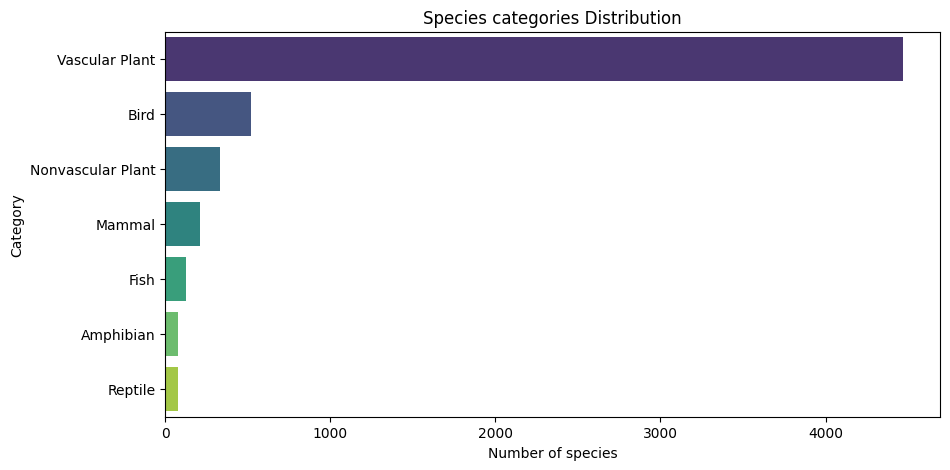

In [4]:
# Category distribution

plt.figure(figsize=(10, 5))
sns.countplot(y=species["category"], order=species["category"].value_counts().index, palette="viridis")
plt.title("Species categories Distribution")
plt.xlabel("Number of species")
plt.ylabel("Category")
plt.show()

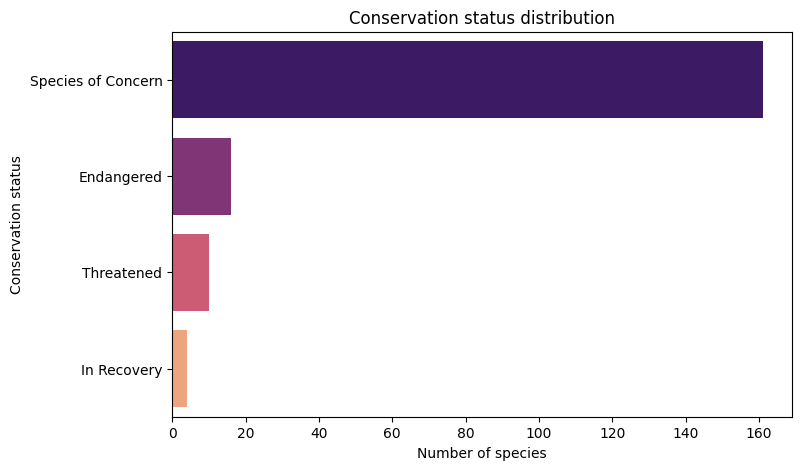

In [5]:
# Conservation status distribution

plt.figure(figsize=(8, 5))
sns.countplot(y=species["conservation_status"].dropna(), order=species["conservation_status"].value_counts().index, palette="magma")
plt.title("Conservation status distribution")
plt.xlabel("Number of species")
plt.ylabel("Conservation status")
plt.show()

<Figure size 1200x600 with 0 Axes>

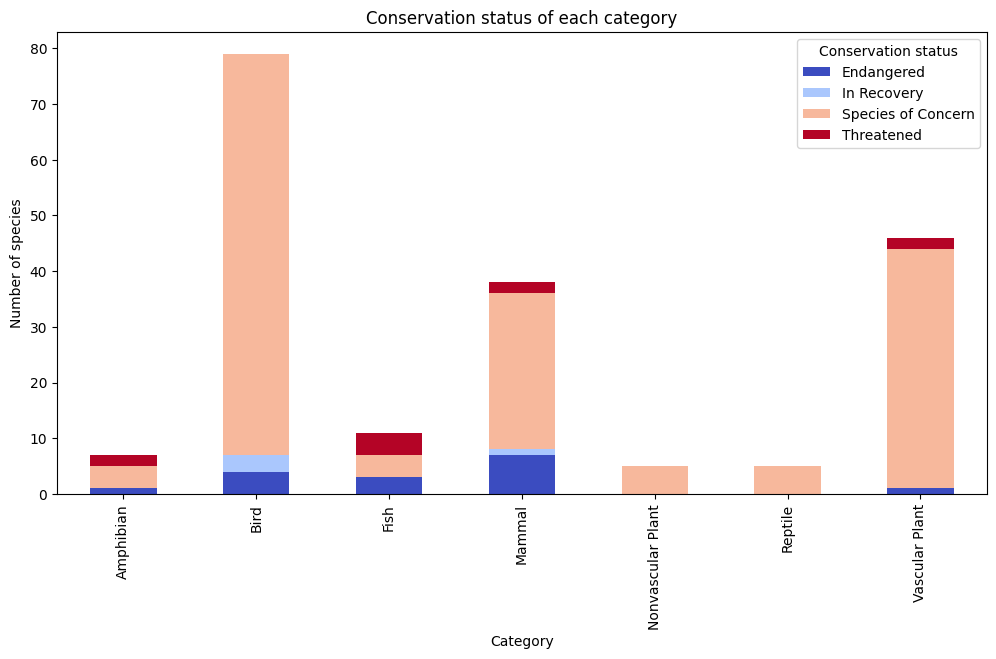

In [6]:
# Conservation status of each category

plt.figure(figsize=(12, 6))
conservation_counts = species.dropna(subset=["conservation_status"]).groupby(["category", "conservation_status"])["scientific_name"].count().unstack().fillna(0)
conservation_counts.plot(kind="bar", stacked=True, figsize=(12,6), colormap="coolwarm")
plt.title("Conservation status of each category")
plt.xlabel("Category")
plt.ylabel("Number of species")
plt.legend(title="Conservation status")
plt.show()

# **2.Species observation analysis**

In [7]:
observation = pd.read_csv("/kaggle/input/national-parks-biodiversity-data/observations.csv")

print(observation.describe())

# Number of species and species

num_parks = observation["park_name"].nunique()
num_species = observation["scientific_name"].nunique()
print(f"Number of parks: {num_parks}")
print(f"Number of species: {num_species}")

#Top 10 most observed species 

top_species = observation.groupby("scientific_name")["observations"].sum().nlargest(10)
print(top_species)

       observations
count  23296.000000
mean     142.287904
std       69.890532
min        9.000000
25%       86.000000
50%      124.000000
75%      195.000000
max      321.000000
Number of parks: 4
Number of species: 5541
scientific_name
Streptopelia decaocto    1785
Holcus lanatus           1780
Castor canadensis        1725
Hypochaeris radicata     1720
Puma concolor            1711
Procyon lotor            1692
Columba livia            1653
Myotis lucifugus         1547
Bidens tripartita        1296
Oxalis dillenii          1276
Name: observations, dtype: int64


**Data visualization**

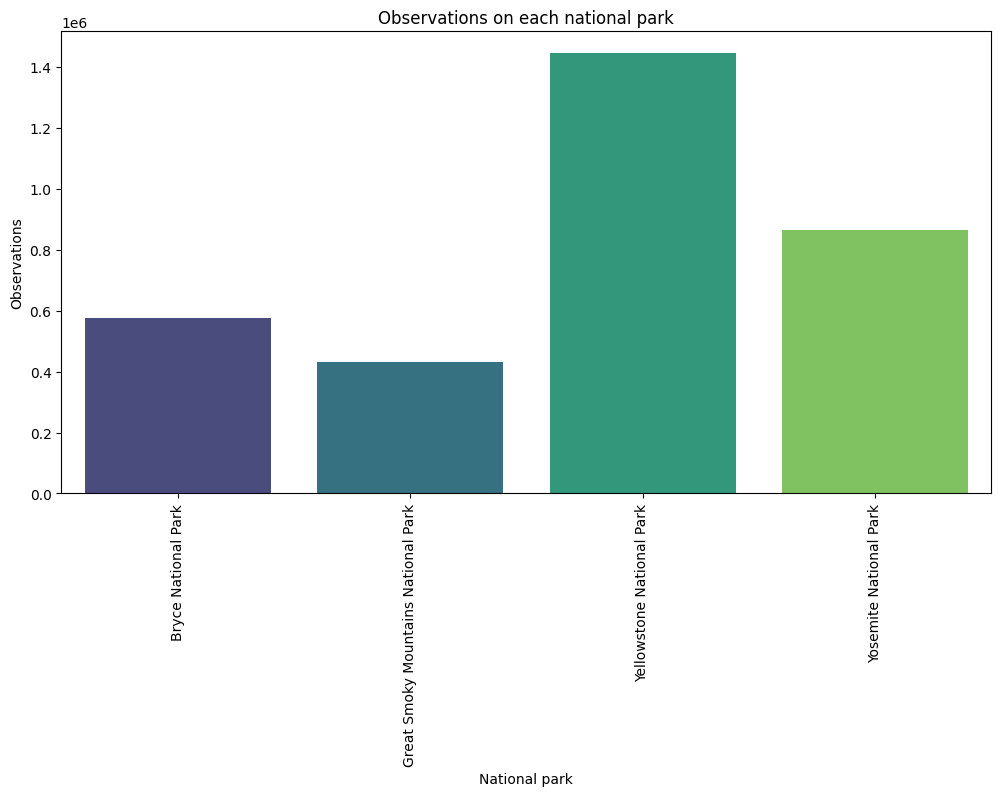

In [8]:
# Observations on each park

obs_park = observation.groupby("park_name")["observations"].sum()

plt.figure(figsize=(12, 6))
sns.barplot(x=obs_park.index, y=obs_park.values, palette="viridis")
plt.xticks(rotation=90)
plt.xlabel("National park")
plt.ylabel("Observations")
plt.title("Observations on each national park")

plt.show()

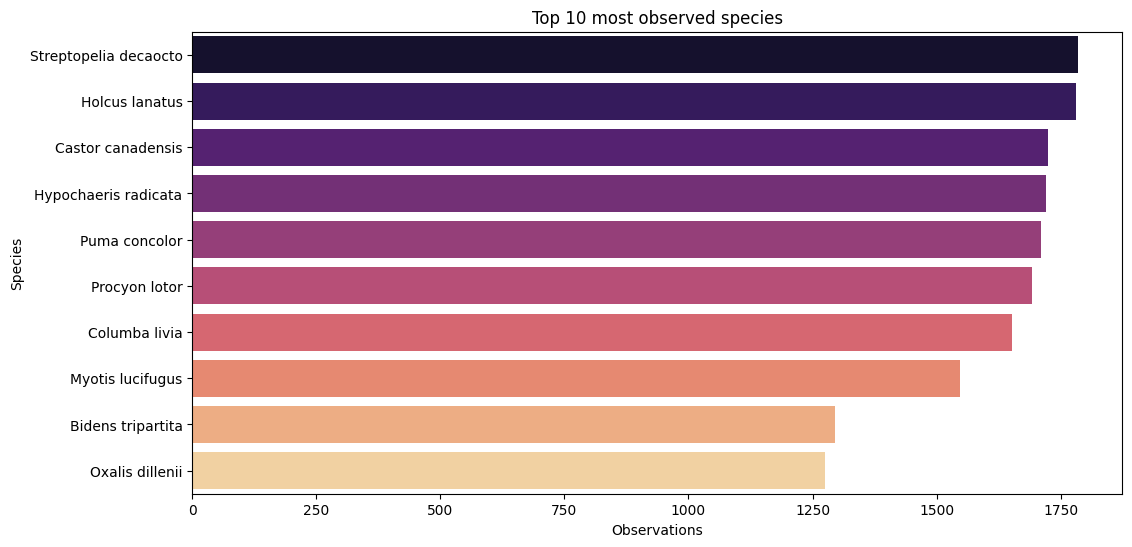

In [9]:
# Top 10 most observed species

plt.figure(figsize=(12, 6))
sns.barplot(x=top_species.values, y=top_species.index, palette="magma")
plt.xlabel("Observations")
plt.ylabel("Species")
plt.title("Top 10 most observed species")

plt.show()


# **3.Database merge and analysis**

In [10]:
observations = pd.read_csv('/kaggle/input/national-parks-biodiversity-data/observations.csv')
species = pd.read_csv('/kaggle/input/national-parks-biodiversity-data/species_info.csv')

merged = pd.merge(observations, species, on='scientific_name', how="inner")
merged.head()
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25632 entries, 0 to 25631
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   scientific_name      25632 non-null  object
 1   park_name            25632 non-null  object
 2   observations         25632 non-null  int64 
 3   category             25632 non-null  object
 4   common_names         25632 non-null  object
 5   conservation_status  880 non-null    object
dtypes: int64(1), object(5)
memory usage: 1.2+ MB


In [11]:
# Summary statistics for numerical columns
summary_stats = merged.describe()

# Check for missing values in the dataset
missing_values = merged.isnull().sum()

# Count unique values in categorical columns
unique_values = merged.nunique()

summary_stats, missing_values, unique_values

(       observations
 count  25632.000000
 mean     142.214693
 std       69.912475
 min        9.000000
 25%       86.000000
 50%      124.000000
 75%      195.000000
 max      321.000000,
 scientific_name            0
 park_name                  0
 observations               0
 category                   0
 common_names               0
 conservation_status    24752
 dtype: int64,
 scientific_name        5541
 park_name                 4
 observations            304
 category                  7
 common_names           5504
 conservation_status       4
 dtype: int64)

In [12]:
# Filter only endangered species
endangered_species = merged[merged["conservation_status"] == "Endangered"]

# Count endangered species by category
endangered_by_category = endangered_species["category"].value_counts()

# Count endangered species by park
endangered_by_park = endangered_species["park_name"].value_counts()

# Calculate the average number of endangered species per park
average_endangered_per_park = endangered_by_park.mean()

endangered_by_category, endangered_by_park, average_endangered_per_park


(category
 Mammal            44
 Bird              16
 Fish              12
 Amphibian          4
 Vascular Plant     4
 Name: count, dtype: int64,
 park_name
 Yosemite National Park                 20
 Bryce National Park                    20
 Yellowstone National Park              20
 Great Smoky Mountains National Park    20
 Name: count, dtype: int64,
 20.0)

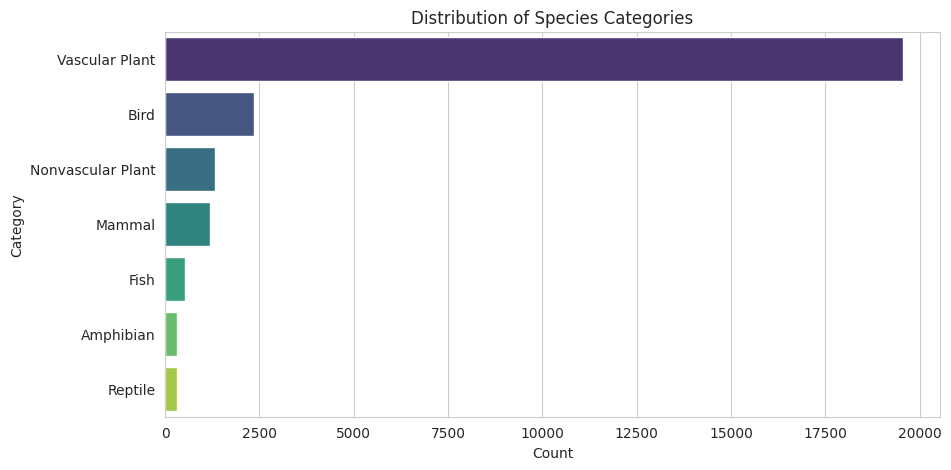

In [13]:
# Set plot style
sns.set_style("whitegrid")

# Countplot for species categories
plt.figure(figsize=(10, 5))
sns.countplot(y=merged["category"], order=merged["category"].value_counts().index, palette="viridis")
plt.xlabel("Count")
plt.ylabel("Category")
plt.title("Distribution of Species Categories")
plt.show()

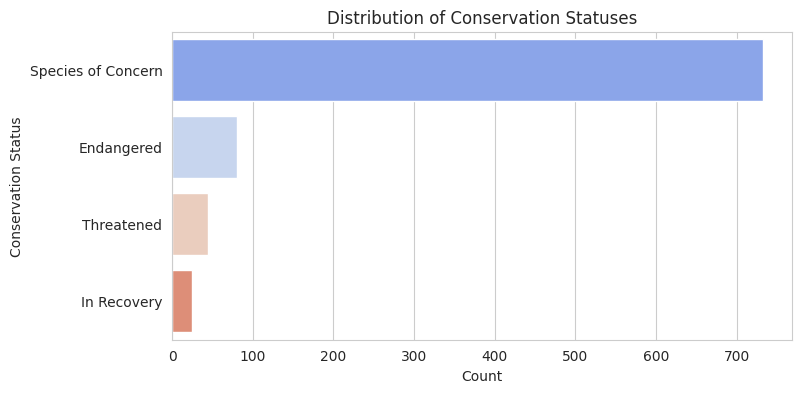

In [14]:
# Countplot for conservation statuses (excluding NaN values)
plt.figure(figsize=(8, 4))
sns.countplot(y=merged["conservation_status"].dropna(), order=merged["conservation_status"].value_counts().index, palette="coolwarm")
plt.xlabel("Count")
plt.ylabel("Conservation Status")
plt.title("Distribution of Conservation Statuses")
plt.show()


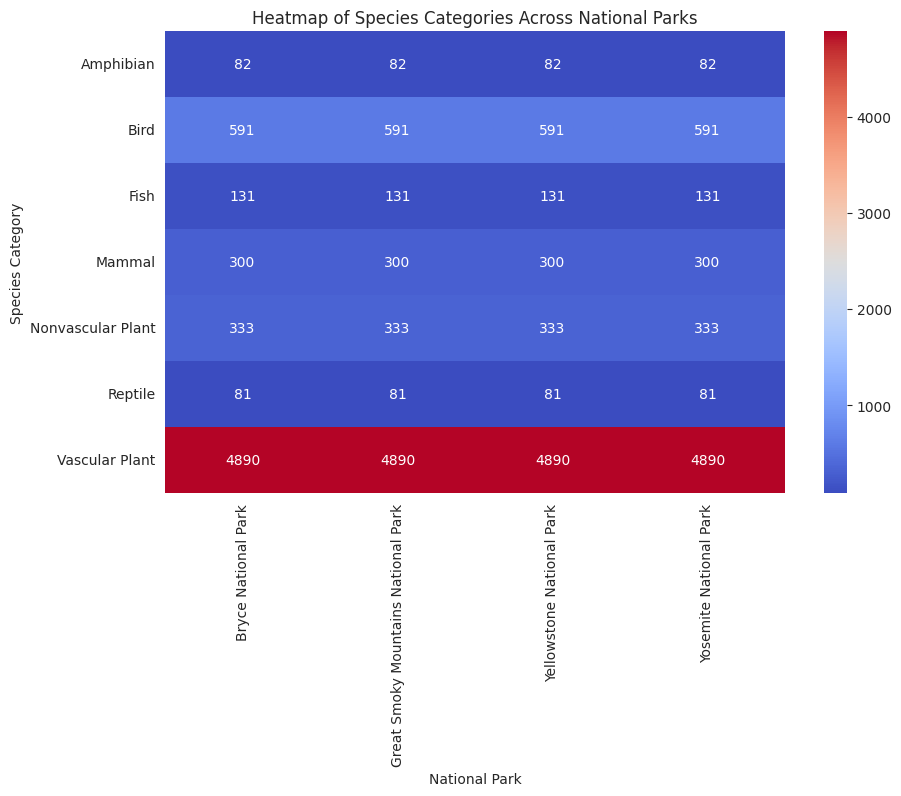

In [15]:
# Create a pivot table for heatmap
df_pivot = merged.pivot_table(index='category', columns='park_name', values='scientific_name', aggfunc='count', fill_value=0)

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df_pivot, annot=True, cmap='coolwarm', fmt='d')
plt.xlabel("National Park")
plt.ylabel("Species Category")
plt.title("Heatmap of Species Categories Across National Parks")
plt.show()

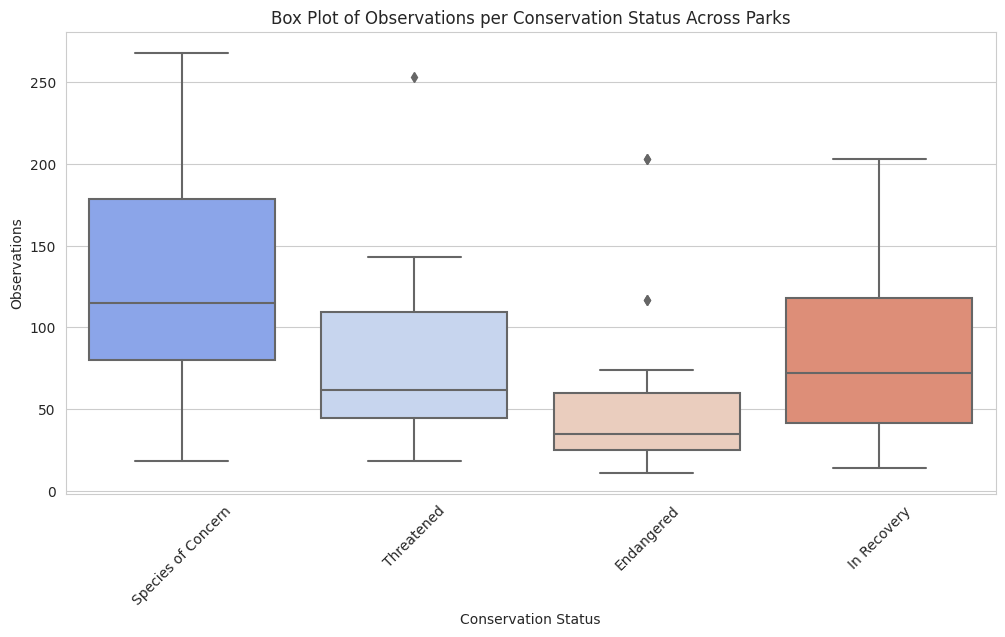

In [16]:
# Calculate the average number of endangered species per park
average_endangered_per_park = endangered_by_park.mean()

# Create a box plot for observations per conservation status across parks
plt.figure(figsize=(12, 6))
sns.boxplot(x='conservation_status', y='observations', data=merged, palette='coolwarm')
plt.xticks(rotation=45)
plt.xlabel("Conservation Status")
plt.ylabel("Observations")
plt.title("Box Plot of Observations per Conservation Status Across Parks")
plt.show()

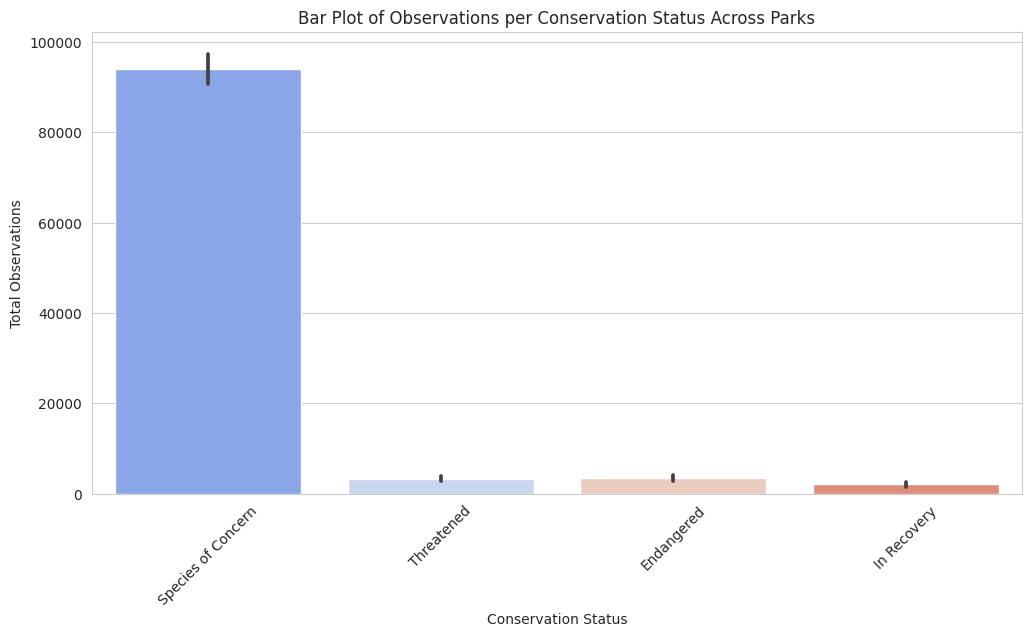

In [17]:
# Create a bar plot for observations per conservation status across parks
plt.figure(figsize=(12, 6))
sns.barplot(x='conservation_status', y='observations', data=merged, palette='coolwarm', estimator=sum)
plt.xticks(rotation=45)
plt.xlabel("Conservation Status")
plt.ylabel("Total Observations")
plt.title("Bar Plot of Observations per Conservation Status Across Parks")
plt.show()

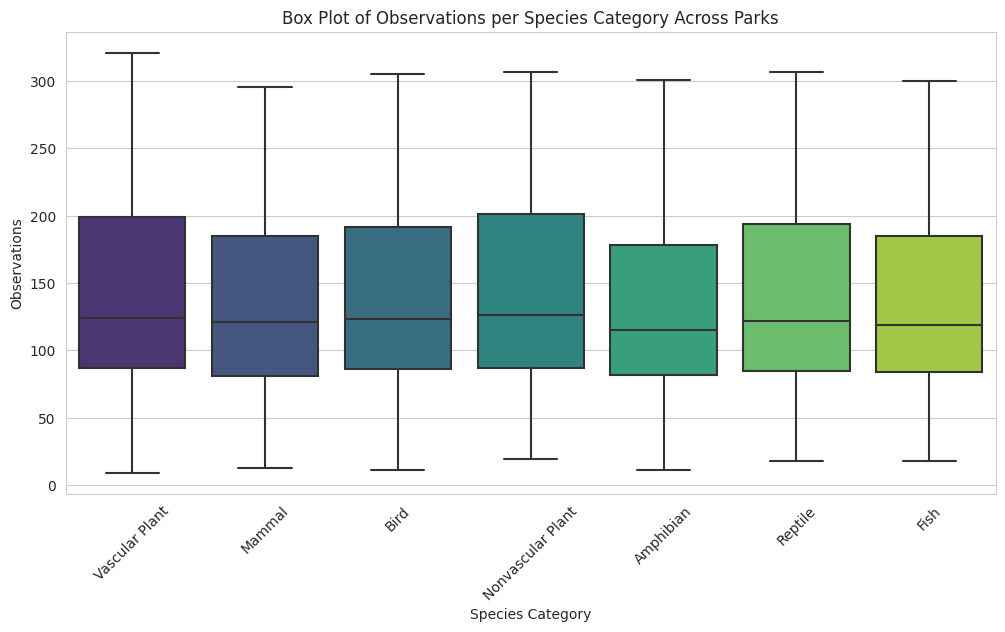

In [18]:
# Create a box plot for species categories across parks
plt.figure(figsize=(12, 6))
sns.boxplot(x='category', y='observations', data=merged, palette='viridis')
plt.xticks(rotation=45)
plt.xlabel("Species Category")
plt.ylabel("Observations")
plt.title("Box Plot of Observations per Species Category Across Parks")
plt.show()

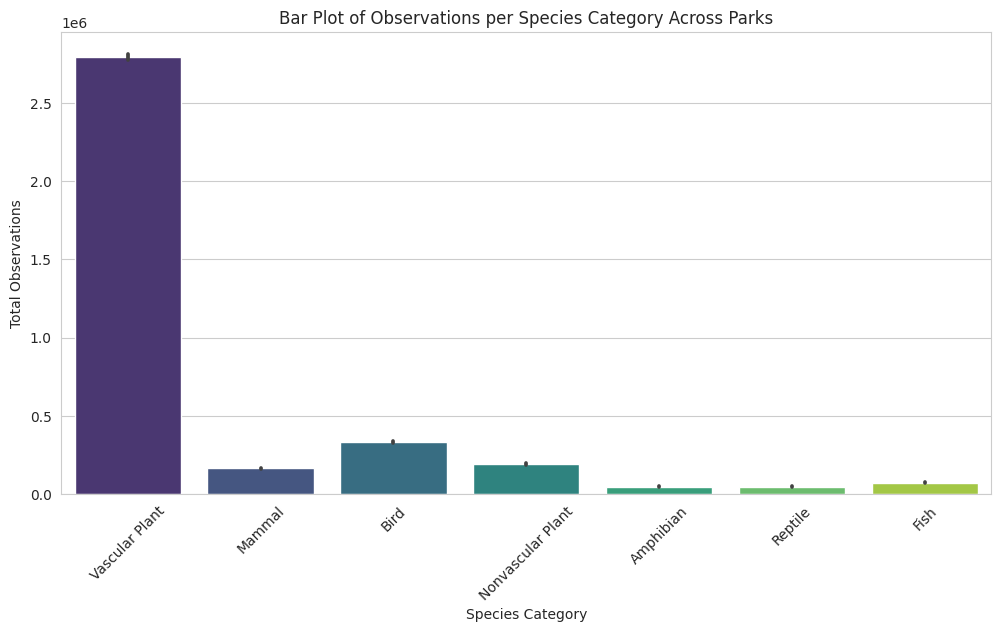

In [19]:
plt.figure(figsize=(12, 6))
sns.barplot(x='category', y='observations', data=merged, palette='viridis', estimator=sum)
plt.xticks(rotation=45)
plt.xlabel("Species Category")
plt.ylabel("Total Observations")
plt.title("Bar Plot of Observations per Species Category Across Parks")
plt.show()